选择一个区域：5N-9N，245E-255E的空间区域，计算这个区域内的平均值，如果目标域与相邻天（从 -4 天到 + 4 天）相比经历了 Pr 异常的单个局部最大值（定义为第 0 天），则将其视为 CCKW 事件。

In [23]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import time
import gc
import pickle
from datetime import datetime
import cmaps
# 配置参数
CACHE_DIR = "./cache/kelvin_wave/"
REGRESSION_CACHE_DIR = os.path.join(CACHE_DIR, "pr_regression_composite")
FIG_SAVE_DIR = "./figures/pr_regression_composite/"

# 创建必要的目录
for d in [CACHE_DIR, REGRESSION_CACHE_DIR, FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

# 分析参数
LEAD_LAG_DAYS = 4  
EQUATOR_LAT = slice(0, 10)     # 用于纬向平均的纬度范围（0-10°N）

# 实验列表
EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📁 Regression cache: {REGRESSION_CACHE_DIR}")
print(f"📁 Figure save directory: {FIG_SAVE_DIR}")
print(f"📊 Lead-lag range: {-LEAD_LAG_DAYS} to {LEAD_LAG_DAYS} days")

print("="*80)
print("="*80)
print("🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis")
print("="*80)
print(f"📅 Notebook started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
def load_filtered_data(var_name, exp_list=None):
    """
    加载滤波后的数据
    
    Parameters:
    -----------
    var_name : str
        变量名称 ('pr', 'ua', 'va', 'omega')
    exp_list : list, optional
        实验列表
    
    Returns:
    --------
    data_dict : dict
        {exp_name: xr.DataArray}
    """
    if exp_list is None:
        exp_list = EXPERIMENTS
    
    data_dict = {}
    
    # 定义可能的缓存目录（按优先级顺序）
    possible_dirs = [
        CACHE_DIR,                                    # ./cache/kelvin_wave/
        "./cache/kelvin_wave_3d/",                    # 3D变量目录
        os.path.join(CACHE_DIR, "../kelvin_wave_3d/") # 相对路径
    ]
    
    print(f"\n📂 Loading {var_name} data...")
    for exp in exp_list:
        loaded = False
        
        # 尝试在不同目录中查找文件
        for cache_dir in possible_dirs:
            cache_file = os.path.join(cache_dir, f'kelvin_{var_name}_{exp.lower()}.nc')
            
            if os.path.exists(cache_file):
                try:
                    data = xr.open_dataarray(cache_file)
                    
                    # 标准化维度名称：将 'level' 重命名为 'lev'（如果存在）
                    if 'level' in data.dims:
                        data = data.rename({'level': 'lev'})
                    
                    data_dict[exp] = data
                    file_size = os.path.getsize(cache_file) / (1024**2)
                    print(f"  ✅ {exp}: Loaded from {os.path.basename(cache_dir)}, "
                          f"Shape={data.shape}, Size={file_size:.1f}MB")
                    loaded = True
                    break
                except Exception as e:
                    print(f"  ❌ {exp}: Error loading from {cache_dir} - {str(e)}")
        
        if not loaded:
            print(f"  ⚠️  {exp}: Cache file not found in any directory!")
    
    return data_dict

print("✅ load_filtered_data 函数定义完成")

📁 Cache directory: ./cache/kelvin_wave/
📁 Regression cache: ./cache/kelvin_wave/pr_regression_composite
📁 Figure save directory: ./figures/pr_regression_composite/
📊 Lead-lag range: -4 to 4 days
🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis
📅 Notebook started at: 2025-12-10 11:27:20
✅ load_filtered_data 函数定义完成


## 🖥️ SLURM 集群加速配置

使用 Dask + SLURM 集群来加速大数据处理，特别是风场复合计算

## 📦 加载已保存的合成数据（可选）

如果已经计算过合成数据，可以使用此功能快速加载，跳过重新计算步骤

In [24]:
def load_saved_composites(composite_dir=None, experiments=None, verbose=True):
    """
    加载已保存的合成降水数据
    
    Parameters:
    -----------
    composite_dir : str, optional
        合成数据存储目录，默认为 './composite_data'
    experiments : list, optional
        要加载的实验列表，默认为 ['CNTL', 'P4K', '4CO2']
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    pr_composites : dict
        {exp_name: composite_mean_data}
    pr_composites_std : dict
        {exp_name: composite_std_data}
    success : bool
        是否成功加载所有数据
    """
    import xarray as xr
    import os
    
    if composite_dir is None:
        composite_dir = os.path.join(os.getcwd(), 'composite_data')
    
    if experiments is None:
        experiments = ['CNTL', 'P4K', '4CO2']
    
    if verbose:
        print("\n" + "="*80)
        print("📂 Loading Saved Composite Data")
        print("="*80)
        print(f"Directory: {composite_dir}")
        print()
    
    pr_composites = {}
    pr_composites_std = {}
    all_success = True
    
    for exp in experiments:
        mean_file = os.path.join(composite_dir, f'pr_composite_mean_{exp.lower()}.nc')
        std_file = os.path.join(composite_dir, f'pr_composite_std_{exp.lower()}.nc')
        
        # 加载平均场
        if os.path.exists(mean_file):
            try:
                pr_composites[exp] = xr.open_dataarray(mean_file)
                if verbose:
                    n_events = pr_composites[exp].attrs.get('n_events', 'N/A')
                    print(f"✅ Loaded {exp} composite mean")
                    print(f"   File: {mean_file}")
                    print(f"   Shape: {pr_composites[exp].shape}")
                    print(f"   Events: {n_events}")
            except Exception as e:
                if verbose:
                    print(f"❌ Failed to load {exp} composite mean: {e}")
                all_success = False
        else:
            if verbose:
                print(f"⚠️  {exp} composite mean file not found: {mean_file}")
            all_success = False
        
        # 加载标准差
        if os.path.exists(std_file):
            try:
                pr_composites_std[exp] = xr.open_dataarray(std_file)
                if verbose:
                    print(f"✅ Loaded {exp} composite std")
                    print(f"   File: {std_file}")
            except Exception as e:
                if verbose:
                    print(f"❌ Failed to load {exp} composite std: {e}")
        else:
            if verbose:
                print(f"⚠️  {exp} composite std file not found: {std_file}")
        
        if verbose:
            print()
    
    if verbose:
        print("="*80)
        if all_success and len(pr_composites) == len(experiments):
            print("✅ All composite data loaded successfully!")
        else:
            print("⚠️  Some data files are missing or failed to load")
            print("   You may need to recompute the composites")
        print("="*80)
    
    return pr_composites, pr_composites_std, all_success


# 使用示例：
# 设置为 True 以尝试加载已保存的数据，False 则跳过直接计算
LOAD_SAVED_COMPOSITES = False

if LOAD_SAVED_COMPOSITES:
    pr_composites_loaded, pr_composites_std_loaded, load_success = load_saved_composites(
        experiments=['CNTL', 'P4K', '4CO2'],
        verbose=True
    )
    
    if load_success:
        print("\n💡 使用已加载的合成数据，可跳过后续的合成计算步骤")
        # 如果成功加载，可以直接使用这些数据
        # pr_composites = pr_composites_loaded
        # pr_composites_std = pr_composites_std_loaded
    else:
        print("\n⚠️  加载失败或数据不完整，需要重新计算合成数据")
else:
    print("⏭️  跳过加载已保存的数据，将重新计算合成数据")

print("\n✅ load_saved_composites 函数定义完成")


⏭️  跳过加载已保存的数据，将重新计算合成数据

✅ load_saved_composites 函数定义完成


In [25]:
def load_detected_events(composite_dir=None, verbose=True):
    """
    加载已保存的事件检测结果
    
    Parameters:
    -----------
    composite_dir : str, optional
        事件数据存储目录，默认为 './composite_data'
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    all_events : dict
        {exp_name: {'event_dates': [...], 'event_intensities': [...], 'n_events': ...}}
    success : bool
        是否成功加载
    """
    import json
    import os
    
    if composite_dir is None:
        composite_dir = os.path.join(os.getcwd(), 'composite_data')
    
    events_file = os.path.join(composite_dir, 'detected_events.json')
    
    if verbose:
        print("\n" + "="*80)
        print("📂 Loading Detected Events")
        print("="*80)
        print(f"File: {events_file}")
        print()
    
    if not os.path.exists(events_file):
        if verbose:
            print(f"⚠️  Event file not found: {events_file}")
            print("   Please run the event detection and save step first.")
        return None, False
    
    try:
        with open(events_file, 'r') as f:
            all_events = json.load(f)
        
        if verbose:
            print("✅ Event detection results loaded successfully!")
            print(f"\n📊 Events summary:")
            for exp, events_info in all_events.items():
                print(f"   {exp}: {events_info['n_events']} events")
                print(f"      Event dates range: {min(events_info['event_dates'])} to {max(events_info['event_dates'])}")
        
        return all_events, True
        
    except Exception as e:
        if verbose:
            print(f"❌ Failed to load events: {e}")
        return None, False


def apply_composite_to_other_variable(variable_data, event_dates, lags, 
                                     exp_name='', verbose=True):
    """
    使用已检测到的事件，对其他变量进行超前滞后合成分析
    
    Parameters:
    -----------
    variable_data : xr.DataArray
        要进行合成分析的变量数据 (time, lat, lon) 或 (time, lev, lat, lon)
    event_dates : list of int
        从降水分析中获得的事件时间索引
    lags : range or list
        lag 天数，应该与降水合成使用相同的范围
    exp_name : str
        实验名称（用于输出）
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    
    Example:
    --------
    # 加载事件信息
    all_events, success = load_detected_events()
    
    # 加载潜热通量数据
    lhf_data = xr.open_dataarray('latent_heat_flux_cntl.nc')
    
    # 使用降水事件对潜热通量进行合成
    lhf_composite, lhf_std, n = apply_composite_to_other_variable(
        lhf_data, 
        all_events['CNTL']['event_dates'], 
        range(-4, 5),
        exp_name='CNTL'
    )
    """
    if verbose:
        print(f"\n{'='*70}")
        print(f"🔄 Computing composite for {exp_name}")
        print(f"{'='*70}")
        print(f"   Variable shape: {variable_data.shape}")
        print(f"   Number of events: {len(event_dates)}")
        print(f"   Lag range: {min(lags)} to {max(lags)} days")
    
    # 使用已有的合成函数
    composite_mean, composite_std, n_events = compute_composite_with_std(
        data=variable_data,
        event_dates=event_dates,
        lags=lags
    )
    
    if verbose:
        if composite_mean is not None:
            print(f"✅ Composite computed successfully")
            print(f"   Valid events used: {n_events}")
            print(f"   Composite shape: {composite_mean.shape}")
            print(f"   Value range: [{composite_mean.min().values:.4e}, {composite_mean.max().values:.4e}]")
        else:
            print(f"❌ Failed to compute composite")
        print(f"{'='*70}")
    
    return composite_mean, composite_std, n_events


print("✅ load_detected_events 和 apply_composite_to_other_variable 函数定义完成")
print("\n💡 使用示例:")
print("   # 1. 加载事件信息")
print("   all_events, success = load_detected_events()")
print("   ")
print("   # 2. 加载其他变量数据（如潜热通量）")
print("   lhf_data = xr.open_dataarray('your_latent_heat_flux_file.nc')")
print("   ")
print("   # 3. 使用相同的事件进行合成分析")
print("   lhf_composite, lhf_std, n = apply_composite_to_other_variable(")
print("       lhf_data,")
print("       all_events['CNTL']['event_dates'],")
print("       range(-4, 5),  # 使用相同的lag范围")
print("       exp_name='CNTL'")
print("   )")


✅ load_detected_events 和 apply_composite_to_other_variable 函数定义完成

💡 使用示例:
   # 1. 加载事件信息
   all_events, success = load_detected_events()
   
   # 2. 加载其他变量数据（如潜热通量）
   lhf_data = xr.open_dataarray('your_latent_heat_flux_file.nc')
   
   # 3. 使用相同的事件进行合成分析
   lhf_composite, lhf_std, n = apply_composite_to_other_variable(
       lhf_data,
       all_events['CNTL']['event_dates'],
       range(-4, 5),  # 使用相同的lag范围
       exp_name='CNTL'
   )


## 🎯 完整示例：使用保存的事件对潜热通量进行合成分析

以下代码展示了如何利用已保存的降水事件信息，对其他变量（如潜热通量）进行相同的超前滞后合成分析

In [26]:
# ============================================================================
# 完整示例：对潜热通量进行合成分析（使用已保存的降水事件）
# ============================================================================

# 设置为 True 来运行此示例
RUN_LHF_COMPOSITE_EXAMPLE = False

if RUN_LHF_COMPOSITE_EXAMPLE:
    print("\n" + "="*80)
    print("📊 示例：使用降水事件对潜热通量进行合成分析")
    print("="*80)
    
    # 步骤1: 加载已保存的事件检测结果
    print("\n📂 步骤1: 加载事件信息...")
    all_events_loaded, events_success = load_detected_events(verbose=True)
    
    if events_success:
        # 步骤2: 加载潜热通量数据（这里需要替换为您的实际文件路径）
        print("\n📂 步骤2: 加载潜热通量数据...")
        print("   ⚠️  请将下面的文件路径替换为您的实际潜热通量数据文件")
        
        # 示例代码（需要根据实际情况修改）:
        # lhf_file_cntl = 'path/to/your/latent_heat_flux_cntl.nc'
        # lhf_data_cntl = xr.open_dataarray(lhf_file_cntl)
        
        # 步骤3: 对每个实验进行合成分析
        print("\n🔄 步骤3: 进行合成分析...")
        
        lhf_composites = {}
        lhf_composites_std = {}
        
        for exp in ['CNTL', 'P4K', '4CO2']:
            if exp in all_events_loaded:
                print(f"\n处理实验: {exp}")
                
                # 这里需要加载对应实验的潜热通量数据
                # lhf_data = xr.open_dataarray(f'path/to/lhf_{exp.lower()}.nc')
                
                # 使用与降水相同的事件和lag范围进行合成
                # lhf_composite, lhf_std, n_events = apply_composite_to_other_variable(
                #     variable_data=lhf_data,
                #     event_dates=all_events_loaded[exp]['event_dates'],
                #     lags=range(-4, 5),  # 使用与降水相同的lag范围
                #     exp_name=exp,
                #     verbose=True
                # )
                
                # lhf_composites[exp] = lhf_composite
                # lhf_composites_std[exp] = lhf_std
                
                print(f"   提示: 请取消注释上面的代码并提供潜热通量数据路径")
        
        # 步骤4: 保存潜热通量合成结果
        print("\n💾 步骤4: 保存潜热通量合成结果...")
        # for exp in lhf_composites.keys():
        #     save_path = f'composite_data/lhf_composite_mean_{exp.lower()}.nc'
        #     lhf_composites[exp].to_netcdf(save_path)
        #     print(f"   ✅ 已保存: {save_path}")
        
        print("\n" + "="*80)
        print("✅ 示例代码框架已准备好，请根据您的数据路径进行调整")
        print("="*80)
    else:
        print("\n⚠️  无法加载事件信息，请先运行完整的notebook生成事件数据")

else:
    print("\n💡 提示: 将 RUN_LHF_COMPOSITE_EXAMPLE 设置为 True 来查看潜热通量合成示例")
    print("   这个示例展示了如何使用已保存的降水事件信息来分析其他变量")



💡 提示: 将 RUN_LHF_COMPOSITE_EXAMPLE 设置为 True 来查看潜热通量合成示例
   这个示例展示了如何使用已保存的降水事件信息来分析其他变量


In [27]:
# # 配置 SLURM 集群以处理大数据
# print("="*70)
# print("🖥️  Setting up SLURM Cluster for distributed computing")
# print("="*70)

# USE_SLURM = True  # 设置为 True 以使用 SLURM 集群

# if USE_SLURM:
#     try:
#         from dask_jobqueue import SLURMCluster
#         from dask.distributed import Client
        
#         cluster = SLURMCluster(
#             name="kelvin_composite",
#             queue="shared",
#             memory="100GB",  # 每个worker的内存
#             cores=64,        # 每个worker的核心数
#             interface="ib0",
#             account="mh1498",  # 您的账户
#             walltime="08:00:00",
#             local_directory="/work/mh1498/m301257/dask-worker-space",
#             log_directory="/work/mh1498/m301257/CCKW_work/logs",
#             scheduler_options={"dashboard_address": ":8788"},
#         )
        
#         client = Client(cluster)
#         cluster.scale(2)  # 启动2个worker，可根据需要调整
        
#         print(f"✅ SLURM Cluster initialized")
#         print(f"📊 Dashboard: {client.dashboard_link}")
#         print(f"🔗 Scheduler: {client.scheduler_info()['address']}")
#         print(f"👷 Workers: Scaling to 2")
#         print("="*70)
#         print("⏳ Waiting for workers to start...")
#         client.wait_for_workers(n_workers=1, timeout=300)  # 等待至少1个worker启动
#         print("✅ Workers ready!")
        
#     except Exception as e:
#         print(f"❌ Failed to initialize SLURM cluster: {e}")
#         print("⚠️  Falling back to local mode")
#         client = None
#         USE_SLURM = False
    
# else:
#     print("⚠️  Running in local mode (no SLURM)")
#     client = None

# print("="*70)

In [28]:
print("\n" + "="*80)
print("STEP 1: Loading filtered precipitation data")
print("="*80)

pr_data_dict = load_filtered_data('pr')

if not pr_data_dict:
    print("❌ No precipitation data found! Please run the filtering step first.")
else:
    print(f"\n✅ Loaded {len(pr_data_dict)} experiments")


STEP 1: Loading filtered precipitation data

📂 Loading pr data...
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB

✅ Loaded 3 experiments
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB

✅ Loaded 3 experiments


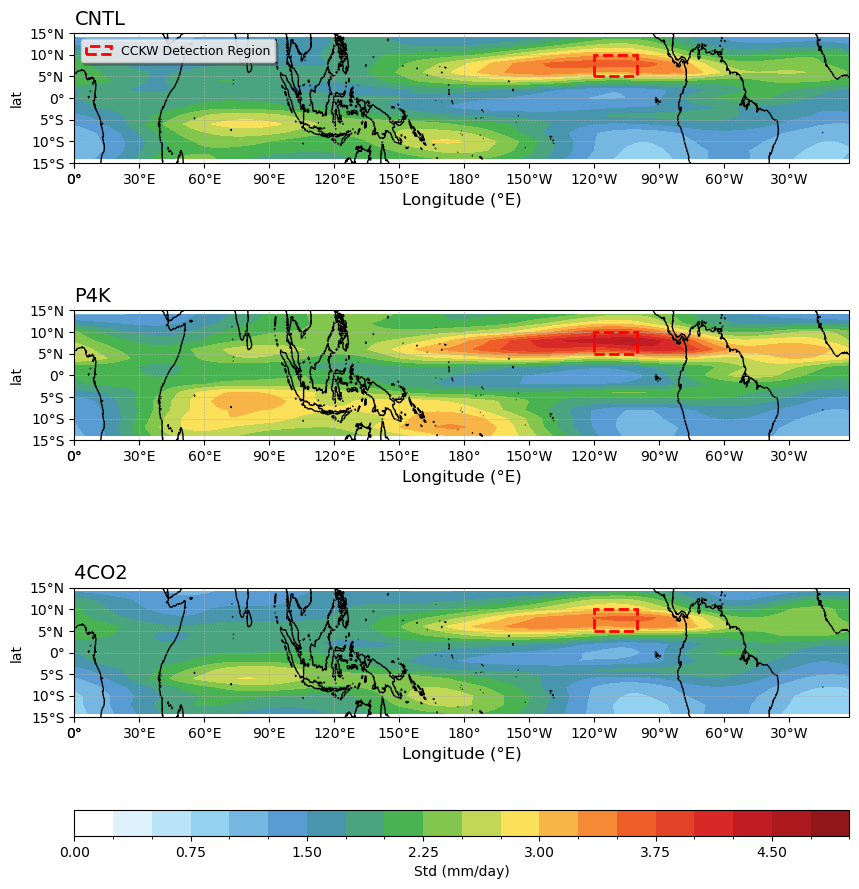

In [29]:
import cartopy.crs as ccrs
import numpy as np
import matplotlib.pyplot as plt
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# 正确的 projection
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    nrows=3, ncols=1,
    figsize=(10, 12),
    subplot_kw={'projection': proj}
)

titles = ['CNTL', 'P4K', '4CO2']

for ax, key in zip(axes, titles):
    
    data = pr_data_dict[key].std('time')  # 具有 0–360 经度的 xarray 数据
    
    # 关键：数据需要告诉 cartopy 它本身是 PlateCarree()
    im = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),   # 数据 CRS
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=np.linspace(0, 5, 21),
        add_colorbar=False,

    )
    
    # 海岸线
    ax.coastlines()
    ax.set_aspect(2)
    
    # ========== 新增：绘制TARGET区域矩形框 ==========
    import matplotlib.patches as mpatches
    # TARGET区域: 5°N-10°N, 240°E-260°E
    target_lon_min, target_lon_max = 240, 260
    target_lat_min, target_lat_max = 5, 10
    
    # 创建矩形框
    rect = mpatches.Rectangle(
        (target_lon_min, target_lat_min),  # 左下角坐标
        target_lon_max - target_lon_min,    # 宽度
        target_lat_max - target_lat_min,    # 高度
        linewidth=2,
        edgecolor='red',
        facecolor='none',
        linestyle='--',
        transform=ccrs.PlateCarree(),
        zorder=10,
        label='CCKW Detection Region'
    )
    ax.add_patch(rect)
    
    # 只在第一个子图添加图例
    if key == 'CNTL':
        ax.legend(loc='upper left', fontsize=9, frameon=True, 
                 fancybox=True, shadow=True, framealpha=0.8)
    # =============================================
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    # 经纬度刻度
    xticks = np.arange(0, 361, 30)
    yticks = np.arange(-15, 16, 5)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)#True/False
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

    # 网格线
    ax.gridlines(xlocs=xticks, ylocs=yticks, linestyle='--', linewidth=0.4)
    ax.set_title(key, fontsize=14, loc='left')
# 单独 colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, aspect=30)
cbar.set_label('Std (mm/day)')


plt.show()


## Step 1.5: Loading Wind Field Data (ua, va)

加载滤波后的风场数据用于合成分析

## Step 2: Define CCKW Event Detection Region and Parameters

Target region: 5°N-9°N, 245°E-255°E  
Event criteria: Local maximum in pr anomaly compared to ±4 days

In [30]:
# ============================================================================
# CCKW Event Detection Parameters
# ============================================================================

# 空间区域：选取目标区域进行平均
TARGET_LAT = slice(5, 11)       # 5°N - 10°N (实际是 5°N - 10°N，slice(5,11) 不包括11)
TARGET_LON = slice(240, 261)    # 240°E - 260°E

# 时间窗口：用于局部最大值检测
EVENT_WINDOW = 4                # ±4 days for local maximum detection
COMPOSITE_LAGS = range(-4, 5)   # -4 to +4 days for composite analysis

# 垂直层选择（用于后续的复合分析）
SELECT_LEV_RANGE = (78, 90)     # Selected level indices: 78-90 (inclusive)

print("="*80)
print("🎯 CCKW Event Detection Configuration")
print("="*80)
print(f"\n📍 Spatial Averaging Region:")
print(f"   Latitude:  {TARGET_LAT.start}°N - {TARGET_LAT.stop-1}°N")
print(f"   Longitude: {TARGET_LON.start}°E - {TARGET_LON.stop-1}°E")
print(f"\n⏱️  Temporal Detection Window:")
print(f"   Event window: ±{EVENT_WINDOW} days")
print(f"   Local maximum definition: Day 0 value > all values in [-{EVENT_WINDOW}, +{EVENT_WINDOW}] days")
print(f"\n📊 Composite Analysis:")
print(f"   Lag range: {min(COMPOSITE_LAGS)} to {max(COMPOSITE_LAGS)} days")
print(f"\n🔬 Vertical Levels (for 3D composites):")
print(f"   Level range: {SELECT_LEV_RANGE[0]} - {SELECT_LEV_RANGE[1]}")
print("="*80)
print("\n💡 Detection Method: Pure local maxima (no threshold filtering)")
print("   ✅ Events are detected purely based on being local maxima")
print("   ✅ No intensity threshold is applied")
print("   ✅ Only positive anomalies (> 0) are considered")
print("="*80)

🎯 CCKW Event Detection Configuration

📍 Spatial Averaging Region:
   Latitude:  5°N - 10°N
   Longitude: 240°E - 260°E

⏱️  Temporal Detection Window:
   Event window: ±4 days
   Local maximum definition: Day 0 value > all values in [-4, +4] days

📊 Composite Analysis:
   Lag range: -4 to 4 days

🔬 Vertical Levels (for 3D composites):
   Level range: 78 - 90

💡 Detection Method: Pure local maxima (no threshold filtering)
   ✅ Events are detected purely based on being local maxima
   ✅ No intensity threshold is applied
   ✅ Only positive anomalies (> 0) are considered


## Step 3: Optimized CCKW Event Detection (Matrix-based)

使用矩阵运算替代循环，大幅提高计算效率

In [31]:
def detect_cckw_events_local_maxima(pr_data, target_lat, target_lon, event_window=4, exp_name=''):
    """
    基于局部最大值的事件检测（不使用阈值）
    
    检测逻辑：
    - 计算空间区域平均（5°N-9°N, 245°E-255°E）
    - 使用矩阵运算在时间上寻找局部最大值
    - 局部最大值定义：第0天的值大于前后±4天窗口内的所有值
    
    Parameters:
    -----------
    pr_data : xr.DataArray
        降水异常数据 (time, lat, lon)
    target_lat : slice
        目标纬度范围（例如 slice(5, 10) 表示 5°N-10°N）
    target_lon : slice
        目标经度范围（例如 slice(240, 260) 表示 240°E-259°E）
    event_window : int, default=4
        事件检测窗口，±event_window 天
    exp_name : str
        实验名称（用于日志输出）
    
    Returns:
    --------
    events : dict
        检测到的事件字典:
        {
            'event_dates': list of int (事件发生的时间索引),
            'event_intensities': list of float (事件的强度值),
            'spatial_mean_ts': xr.DataArray (完整的空间平均时间序列),
            'n_events': int (事件总数)
        }
    """
    print(f"\n{'='*70}")
    print(f"🔍 Detecting CCKW Events: {exp_name}")
    print(f"{'='*70}")
    
    # 1. 计算目标区域的空间平均
    print(f"📍 Target region: {target_lat.start}°N-{target_lat.stop}°N, "
          f"{target_lon.start}°E-{target_lon.stop}°E")
    
    pr_target = pr_data.sel(lat=target_lat, lon=target_lon)
    spatial_mean = pr_target.mean(dim=['lat', 'lon'])
    
    # 转换为 numpy 数组以加速计算
    values = spatial_mean.values
    n_times = len(values)
    
    print(f"📊 Spatial mean time series: shape={spatial_mean.shape}")
    print(f"   Value range: [{values.min():.4f}, {values.max():.4f}] mm/day")
    
    # 2. 使用矩阵运算检测局部最大值
    print(f"\n🔎 Detecting local maxima (pure definition)...")
    print(f"   Event window: ±{event_window} days")
    print(f"   Criterion: Day 0 must be the maximum in the window")
    print(f"   Scanning {n_times} time steps...")
    
    # 创建布尔数组标记局部最大值
    is_local_max = np.zeros(n_times, dtype=bool)
    
    # 向量化检测局部最大值（纯粹的定义，不加额外约束）
    for i in range(event_window, n_times - event_window):
        window_start = i - event_window
        window_end = i + event_window + 1
        window_values = values[window_start:window_end]
        
        # 局部最大值条件：
        # 1. 是窗口内的最大值
        # 2. 值必须大于0（只考虑正异常）
        # 注：不添加其他约束，让后续的复合分析来自然筛选真实的Kelvin波事件
        if values[i] == window_values.max() and values[i] > 0:
            is_local_max[i] = True
    
    # 获取所有局部最大值的索引和强度
    event_indices = np.where(is_local_max)[0]
    event_intensities = values[event_indices]
    
    print(f"\n✅ Detection complete!")
    print(f"   Total events found: {len(event_indices)}")
    
    # 3. 统计信息
    if len(event_intensities) > 0:
        print(f"\n📈 Event intensity statistics:")
        print(f"   Mean:   {event_intensities.mean():.4e} mm/day")
        print(f"   Std:    {event_intensities.std():.4e} mm/day")
        print(f"   Min:    {event_intensities.min():.4e} mm/day")
        print(f"   Max:    {event_intensities.max():.4e} mm/day")
        print(f"   Median: {np.median(event_intensities):.4e} mm/day")
        print(f"   25th percentile: {np.percentile(event_intensities, 25):.4e} mm/day")
        print(f"   75th percentile: {np.percentile(event_intensities, 75):.4e} mm/day")
    else:
        print("\n⚠️  No events detected!")
    
    # 构建返回字典
    events = {
        'event_dates': event_indices.tolist(),
        'event_intensities': event_intensities.tolist(),
        'spatial_mean_ts': spatial_mean,
        'n_events': len(event_indices)
    }
    
    print(f"{'='*70}")
    
    return events

print("✅ detect_cckw_events_local_maxima function defined")

✅ detect_cckw_events_local_maxima function defined


## Step 4: Run Event Detection (Local Maxima Only)

使用矩阵运算检测局部最大值事件（不使用阈值筛选）

In [32]:
import time

print("\n" + "="*80)
print("STEP 4: Detecting CCKW Events - Local Maxima Only (No Threshold)")
print("="*80)
print("🎯 Detection method: Pure local maximum in ±4 day window")
print("📍 Target region: 5°N-9°N, 245°E-255°E (spatial average)")
print("="*80)

all_events = {}
timing_results = {}

for exp in EXPERIMENTS:
    if exp not in pr_data_dict:
        print(f"⚠️  Skipping {exp}: No data available")
        continue
    
    pr_data = pr_data_dict[exp]
    
    # 计时
    start_time = time.time()
    
    # 使用新的局部最大值检测函数（不使用阈值）
    events = detect_cckw_events_local_maxima(
        pr_data=pr_data,
        target_lat=TARGET_LAT,
        target_lon=TARGET_LON,
        event_window=EVENT_WINDOW,
        exp_name=exp
    )
    
    elapsed_time = time.time() - start_time
    timing_results[exp] = elapsed_time
    
    all_events[exp] = events
    print(f"⏱️  Computation time: {elapsed_time:.3f} seconds\n")

print("\n" + "="*80)
print("✅ Event Detection Complete (Local Maxima Method)")
print("="*80)
print(f"\n📊 Summary:")
for exp, events in all_events.items():
    print(f"   {exp}: {events['n_events']} events detected (in {timing_results[exp]:.3f}s)")


STEP 4: Detecting CCKW Events - Local Maxima Only (No Threshold)
🎯 Detection method: Pure local maximum in ±4 day window
📍 Target region: 5°N-9°N, 245°E-255°E (spatial average)

🔍 Detecting CCKW Events: CNTL
📍 Target region: 5°N-11°N, 240°E-261°E
📊 Spatial mean time series: shape=(5114,)
   Value range: [-5.4457, 6.1986] mm/day

🔎 Detecting local maxima (pure definition)...
   Event window: ±4 days
   Criterion: Day 0 must be the maximum in the window
   Scanning 5114 time steps...

✅ Detection complete!
   Total events found: 546

📈 Event intensity statistics:
   Mean:   2.1662e+00 mm/day
   Std:    1.0413e+00 mm/day
   Min:    1.0931e-01 mm/day
   Max:    6.1986e+00 mm/day
   Median: 2.0597e+00 mm/day
   25th percentile: 1.4251e+00 mm/day
   75th percentile: 2.7718e+00 mm/day
⏱️  Computation time: 0.012 seconds


🔍 Detecting CCKW Events: P4K
📍 Target region: 5°N-11°N, 240°E-261°E
📊 Spatial mean time series: shape=(5114,)
   Value range: [-7.0937, 9.1617] mm/day

🔎 Detecting local ma

## 🔍 验证：局部最大值检测逻辑

展示一个事件示例，验证局部最大值的检测逻辑

In [33]:
# 验证：选择一个检测到的事件，查看其前后±4天的值
import pandas as pd

exp_to_check = 'CNTL'
events = all_events[exp_to_check]

# 选择第10个事件（任意选择）
if events['n_events'] > 10:
    event_idx = 10
    event_time_idx = events['event_dates'][event_idx]
    event_intensity = events['event_intensities'][event_idx]
    
    print("="*80)
    print(f"🔍 Verifying Event Detection Logic - {exp_to_check}")
    print("="*80)
    print(f"\n📌 Selected Event: #{event_idx+1}")
    print(f"   Time Index: {event_time_idx}")
    print(f"   Intensity (Day 0): {event_intensity:.4f} mm/day")
    
    # 获取前后4天的值
    spatial_mean = events['spatial_mean_ts']
    values = spatial_mean.values
    
    window_start = event_time_idx - EVENT_WINDOW
    window_end = event_time_idx + EVENT_WINDOW + 1
    
    # 创建数据表格
    window_data = []
    for offset in range(-EVENT_WINDOW, EVENT_WINDOW + 1):
        idx = event_time_idx + offset
        value = values[idx]
        is_max = (offset == 0)
        window_data.append({
            'Day': f'Day {offset:+d}' if offset != 0 else 'Day 0 (Event)',
            'Time Index': idx,
            'Value (mm/day)': f'{value:.4f}',
            'Is Maximum?': '✅ YES' if is_max else ('❌ No' if value < event_intensity else '⚠️  Equal')
        })
    
    df = pd.DataFrame(window_data)
    
    print(f"\n📊 Values in ±{EVENT_WINDOW} day window:")
    print(df.to_string(index=False))
    
    # 验证
    window_values = values[window_start:window_end]
    max_value = window_values.max()
    
    print(f"\n✅ Verification:")
    print(f"   Maximum value in window: {max_value:.4f} mm/day")
    print(f"   Event day value (Day 0): {event_intensity:.4f} mm/day")
    print(f"   Is Day 0 the maximum? {event_intensity == max_value}")
    print(f"   Is Day 0 positive? {event_intensity > 0}")
    
    if event_intensity == max_value and event_intensity > 0:
        print(f"\n   ✅ This event meets ALL criteria for local maximum!")
    else:
        print(f"\n   ❌ Warning: This event does NOT meet the criteria!")
    
    print("="*80)
else:
    print(f"Not enough events to verify (found {events['n_events']})")

🔍 Verifying Event Detection Logic - CNTL

📌 Selected Event: #11
   Time Index: 113
   Intensity (Day 0): 2.0016 mm/day

📊 Values in ±4 day window:
          Day  Time Index Value (mm/day) Is Maximum?
       Day -4         109         1.8491        ❌ No
       Day -3         110        -0.2491        ❌ No
       Day -2         111        -1.6305        ❌ No
       Day -1         112         0.9184        ❌ No
Day 0 (Event)         113         2.0016       ✅ YES
       Day +1         114        -1.0791        ❌ No
       Day +2         115        -2.2368        ❌ No
       Day +3         116         0.5708        ❌ No
       Day +4         117         1.7937        ❌ No

✅ Verification:
   Maximum value in window: 2.0016 mm/day
   Event day value (Day 0): 2.0016 mm/day
   Is Day 0 the maximum? True
   Is Day 0 positive? True

   ✅ This event meets ALL criteria for local maximum!


In [34]:
all_events.keys()

dict_keys(['CNTL', 'P4K', '4CO2'])

In [35]:
all_events['CNTL'].keys()

dict_keys(['event_dates', 'event_intensities', 'spatial_mean_ts', 'n_events'])

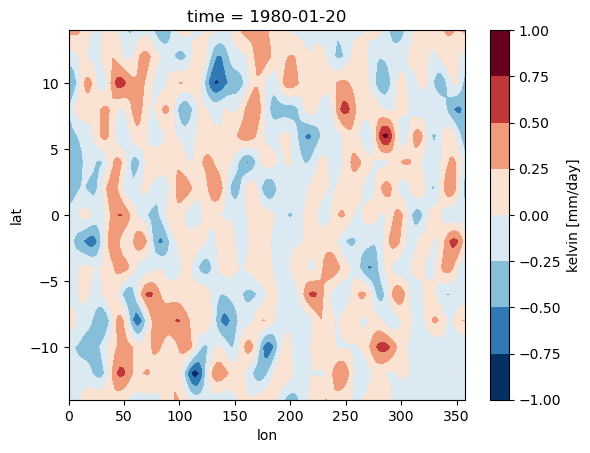

In [36]:
pr_data_dict['CNTL'][19].plot.contourf()

### 5.5 优化的矩阵化合成函数（支持Dask并行）

使用矩阵运算和Dask延迟计算来加速合成分析

In [37]:
from tqdm import tqdm
import dask
import dask.array as da

def compute_composite_optimized(data, event_dates, lags, use_dask=True, desc="Computing"):
    """
    优化的矩阵化合成分析函数，支持进度显示和Dask并行
    
    Parameters:
    -----------
    data : xr.DataArray
        原始数据 (time, lat, lon)
    event_dates : list of int
        事件发生的时间索引列表
    lags : range or list
        lag 天数
    use_dask : bool
        是否使用Dask并行计算
    desc : str
        进度条描述
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    """
    import time
    start_time = time.time()
    
    lags_list = list(lags)
    n_lags = len(lags_list)
    min_lag, max_lag = min(lags_list), max(lags_list)
    
    # 1. 筛选有效事件（矩阵化边界检查）
    event_dates_array = np.array(event_dates)
    valid_mask = (event_dates_array + min_lag >= 0) & (event_dates_array + max_lag < len(data.time))
    valid_events = event_dates_array[valid_mask]
    n_events = len(valid_events)
    
    if n_events == 0:
        return None, None, 0
    
    print(f"   Valid events: {n_events}/{len(event_dates)}")
    
    # 2. 构建索引矩阵 (n_events, n_lags)
    # 每行是一个事件，每列是一个lag
    event_indices = valid_events[:, np.newaxis] + np.array(lags_list)[np.newaxis, :]
    
    # 3. 一次性提取所有数据（矩阵化索引）
    print(f"   Extracting data with shape: ({n_events}, {n_lags}, {len(data.lat)}, {len(data.lon)})")
    
    if use_dask and hasattr(data.data, 'chunks'):
        # 使用Dask延迟计算
        composite_data = data.isel(time=event_indices.ravel()).values.reshape(
            n_events, n_lags, len(data.lat), len(data.lon)
        )
    else:
        # 使用NumPy（适合小数据）
        composite_data = data.values[event_indices]  # (n_events, n_lags, lat, lon)
    
    # 4. 沿事件维度计算平均和标准差（矩阵运算）
    print(f"   Computing statistics...")
    composite_mean_data = np.mean(composite_data, axis=0)  # (n_lags, lat, lon)
    composite_std_data = np.std(composite_data, axis=0, ddof=1)  # (n_lags, lat, lon)
    
    # 5. 转换回xarray
    composite_mean = xr.DataArray(
        composite_mean_data,
        dims=['lag', 'lat', 'lon'],
        coords={
            'lag': lags_list,
            'lat': data.lat,
            'lon': data.lon
        }
    )
    
    composite_std = xr.DataArray(
        composite_std_data,
        dims=['lag', 'lat', 'lon'],
        coords={
            'lag': lags_list,
            'lat': data.lat,
            'lon': data.lon
        }
    )
    
    # 添加元数据
    composite_mean.attrs['n_events'] = n_events
    composite_std.attrs['n_events'] = n_events
    
    elapsed = time.time() - start_time
    print(f"   ⏱️  Completed in {elapsed:.2f}s")
    
    return composite_mean, composite_std, n_events


print("✅ Optimized composite function defined")
print("   Features:")
print("   - Vectorized indexing (no loops)")
print("   - Matrix operations for mean/std")
print("   - Dask support for large datasets")
print("   - Progress tracking")

✅ Optimized composite function defined
   Features:
   - Vectorized indexing (no loops)
   - Matrix operations for mean/std
   - Dask support for large datasets
   - Progress tracking


In [38]:
def compute_composite(data, event_dates, lags):
    """
    计算给定事件列表的 lead-lag 复合分析
    
    Parameters:
    -----------
    data : xr.DataArray
        原始数据 (time, lat, lon) 或 (time, lev, lat, lon)
    event_dates : list of int
        事件发生的时间索引列表
    lags : range or list
        lag 天数，例如 range(-4, 5) 表示 -4 到 +4 天
    
    Returns:
    --------
    composite : xr.DataArray
        复合场 (lag, lat, lon) 或 (lag, lev, lat, lon)
    """
    composites = []
    n_valid_events = 0
    
    for event_idx in event_dates:
        # 检查边界，确保 lag 范围内的数据都存在
        if event_idx + min(lags) < 0 or event_idx + max(lags) >= len(data.time):
            continue
        
        # 提取该事件的 lead-lag 数据
        event_composite = []
        for lag in lags:
            event_composite.append(data.isel(time=event_idx + lag))
        
        # 沿新的 lag 维度堆叠
        event_composite = xr.concat(event_composite, dim='lag')
        composites.append(event_composite)
        n_valid_events += 1
    
    # 对所有事件求平均
    if len(composites) > 0:
        composite = xr.concat(composites, dim='event').mean(dim='event')
        composite['lag'] = list(lags)
        
        # 添加有效事件数作为属性
        composite.attrs['n_events'] = n_valid_events
    else:
        composite = None
    
    return composite


def compute_composite_with_std(data, event_dates, lags):
    """
    计算复合分析及其标准差（用于显著性检验）
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    """
    composites = []
    
    for event_idx in event_dates:
        if event_idx + min(lags) < 0 or event_idx + max(lags) >= len(data.time):
            continue
        
        event_composite = []
        for lag in lags:
            event_composite.append(data.isel(time=event_idx + lag))
        
        event_composite = xr.concat(event_composite, dim='lag')
        composites.append(event_composite)
    
    if len(composites) > 0:
        # 沿事件维度堆叠
        all_composites = xr.concat(composites, dim='event')
        
        # 计算平均和标准差
        composite_mean = all_composites.mean(dim='event')
        composite_std = all_composites.std(dim='event')
        
        composite_mean['lag'] = list(lags)
        composite_std['lag'] = list(lags)
        
        n_events = len(composites)
    else:
        composite_mean = None
        composite_std = None
        n_events = 0
    
    return composite_mean, composite_std, n_events


print("✅ Composite analysis functions defined")

✅ Composite analysis functions defined


### 6.1 计算降水场的复合分析

In [39]:
print("\n" + "="*80)
print("STEP 6.1: Computing Precipitation Composites")
print("="*80)

# 存储所有实验的复合结果
pr_composites = {}
pr_composites_std = {}

for exp in EXPERIMENTS:
    if exp not in all_events or exp not in pr_data_dict:
        print(f"⚠️  Skipping {exp}: Missing data or events")
        continue
    
    print(f"\n{'='*70}")
    print(f"🔄 Computing composite for {exp}")
    print(f"{'='*70}")
    
    event_dates = all_events[exp]['event_dates']
    pr_data = pr_data_dict[exp]
    
    # 计算复合分析（带标准差）
    composite_mean, composite_std, n_events = compute_composite_with_std(
        data=pr_data,
        event_dates=event_dates,
        lags=COMPOSITE_LAGS
    )
    
    if composite_mean is not None:
        pr_composites[exp] = composite_mean
        pr_composites_std[exp] = composite_std
        
        print(f"✅ Composite computed successfully")
        print(f"   Valid events used: {n_events}")
        print(f"   Composite shape: {composite_mean.shape}")
        print(f"   Lag range: {min(COMPOSITE_LAGS)} to {max(COMPOSITE_LAGS)} days")
        print(f"   Value range: [{composite_mean.min().values:.4f}, {composite_mean.max().values:.4f}] mm/day")
    else:
        print(f"❌ Failed to compute composite for {exp}")

print("\n" + "="*80)
print("✅ All Precipitation Composites Computed")
print("="*80)
print(f"\n📊 Summary:")
for exp in pr_composites.keys():
    n_events = pr_composites[exp].attrs.get('n_events', 'N/A')
    print(f"   {exp}: {n_events} events")


STEP 6.1: Computing Precipitation Composites

🔄 Computing composite for CNTL
✅ Composite computed successfully
   Valid events used: 546
   Composite shape: (9, 15, 180)
   Lag range: -4 to 4 days
   Value range: [-1.6942, 3.2012] mm/day

🔄 Computing composite for P4K
✅ Composite computed successfully
   Valid events used: 546
   Composite shape: (9, 15, 180)
   Lag range: -4 to 4 days
   Value range: [-1.6942, 3.2012] mm/day

🔄 Computing composite for P4K
✅ Composite computed successfully
   Valid events used: 548
   Composite shape: (9, 15, 180)
   Lag range: -4 to 4 days
   Value range: [-2.0265, 3.9152] mm/day

🔄 Computing composite for 4CO2
✅ Composite computed successfully
   Valid events used: 548
   Composite shape: (9, 15, 180)
   Lag range: -4 to 4 days
   Value range: [-2.0265, 3.9152] mm/day

🔄 Computing composite for 4CO2
✅ Composite computed successfully
   Valid events used: 552
   Composite shape: (9, 15, 180)
   Lag range: -4 to 4 days
   Value range: [-1.7272, 3.2118

In [40]:
# 保存合成的降水数据
print("\n" + "="*80)
print("💾 Saving Precipitation Composites to NetCDF files")
print("="*80)

# 创建保存目录（如果不存在）
COMPOSITE_SAVE_DIR = os.path.join(os.getcwd(), 'composite_data')
os.makedirs(COMPOSITE_SAVE_DIR, exist_ok=True)
print(f"📁 Save directory: {COMPOSITE_SAVE_DIR}")

# 保存每个实验的合成数据
for exp in EXPERIMENTS:
    if exp not in pr_composites:
        print(f"⚠️  Skipping {exp}: No composite data available")
        continue
    
    # 保存复合平均场
    composite_mean = pr_composites[exp]
    mean_filename = f'pr_composite_mean_{exp.lower()}.nc'
    mean_filepath = os.path.join(COMPOSITE_SAVE_DIR, mean_filename)
    
    # 添加元数据
    composite_mean.attrs['description'] = f'Composite mean precipitation for {exp}'
    composite_mean.attrs['units'] = 'mm/day'
    composite_mean.attrs['n_events'] = composite_mean.attrs.get('n_events', 'N/A')
    composite_mean.attrs['lag_range'] = f"{min(COMPOSITE_LAGS)} to {max(COMPOSITE_LAGS)} days"
    composite_mean.attrs['created_date'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    
    composite_mean.to_netcdf(mean_filepath)
    print(f"✅ Saved: {mean_filename}")
    print(f"   Path: {mean_filepath}")
    print(f"   Shape: {composite_mean.shape}")
    print(f"   Events: {composite_mean.attrs.get('n_events', 'N/A')}")
    
    # 保存复合标准差
    if exp in pr_composites_std:
        composite_std = pr_composites_std[exp]
        std_filename = f'pr_composite_std_{exp.lower()}.nc'
        std_filepath = os.path.join(COMPOSITE_SAVE_DIR, std_filename)
        
        composite_std.attrs['description'] = f'Composite standard deviation for {exp}'
        composite_std.attrs['units'] = 'mm/day'
        composite_std.attrs['n_events'] = composite_std.attrs.get('n_events', 'N/A')
        composite_std.attrs['lag_range'] = f"{min(COMPOSITE_LAGS)} to {max(COMPOSITE_LAGS)} days"
        composite_std.attrs['created_date'] = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
        
        composite_std.to_netcdf(std_filepath)
        print(f"✅ Saved: {std_filename}")
        print(f"   Path: {std_filepath}")
    
    print()

print("="*80)
print("✅ All composite data saved successfully!")
print(f"📂 Files are stored in: {COMPOSITE_SAVE_DIR}")
print("="*80)

# 显示如何加载这些文件的示例代码
print("\n💡 To load these files in the future, use:")
print("```python")
print("import xarray as xr")
print("import os")
print()
print("# Set the directory path")
print(f"composite_dir = '{COMPOSITE_SAVE_DIR}'")
print()
print("# Load composite data for each experiment")
print("pr_composites = {}")
print("pr_composites_std = {}")
print()
print("for exp in ['CNTL', 'P4K', '4CO2']:")
print("    mean_file = os.path.join(composite_dir, f'pr_composite_mean_{exp.lower()}.nc')")
print("    std_file = os.path.join(composite_dir, f'pr_composite_std_{exp.lower()}.nc')")
print("    ")
print("    if os.path.exists(mean_file):")
print("        pr_composites[exp] = xr.open_dataarray(mean_file)")
print("        print(f'✅ Loaded {exp} composite mean')")
print("    ")
print("    if os.path.exists(std_file):")
print("        pr_composites_std[exp] = xr.open_dataarray(std_file)")
print("        print(f'✅ Loaded {exp} composite std')")
print("```")
print()



💾 Saving Precipitation Composites to NetCDF files
📁 Save directory: /work/mh1498/m301257/composite_data
✅ Saved: pr_composite_mean_cntl.nc
   Path: /work/mh1498/m301257/composite_data/pr_composite_mean_cntl.nc
   Shape: (9, 15, 180)
   Events: N/A
✅ Saved: pr_composite_std_cntl.nc
   Path: /work/mh1498/m301257/composite_data/pr_composite_std_cntl.nc

✅ Saved: pr_composite_mean_p4k.nc
   Path: /work/mh1498/m301257/composite_data/pr_composite_mean_p4k.nc
   Shape: (9, 15, 180)
   Events: N/A
✅ Saved: pr_composite_std_p4k.nc
   Path: /work/mh1498/m301257/composite_data/pr_composite_std_p4k.nc

✅ Saved: pr_composite_mean_4co2.nc
   Path: /work/mh1498/m301257/composite_data/pr_composite_mean_4co2.nc
   Shape: (9, 15, 180)
   Events: N/A
✅ Saved: pr_composite_std_4co2.nc
   Path: /work/mh1498/m301257/composite_data/pr_composite_std_4co2.nc

✅ All composite data saved successfully!
📂 Files are stored in: /work/mh1498/m301257/composite_data

💡 To load these files in the future, use:
```python

In [41]:
# 保存事件检测结果（用于其他变量的合成分析）
print("\n" + "="*80)
print("💾 Saving Event Detection Results")
print("="*80)

import json
import numpy as np

# 保存事件信息到JSON文件（方便后续加载）
events_save_path = os.path.join(COMPOSITE_SAVE_DIR, 'detected_events.json')

# 将事件信息转换为可序列化的格式
events_to_save = {}
for exp in EXPERIMENTS:
    if exp in all_events:
        events_to_save[exp] = {
            'event_dates': all_events[exp]['event_dates'],
            'event_intensities': all_events[exp]['event_intensities'],
            'n_events': all_events[exp]['n_events']
        }

# 保存到JSON
with open(events_save_path, 'w') as f:
    json.dump(events_to_save, f, indent=2)

print(f"✅ Event detection results saved to: {events_save_path}")
print(f"\n📊 Saved events summary:")
for exp, events_info in events_to_save.items():
    print(f"   {exp}: {events_info['n_events']} events")

print("\n💡 用途说明:")
print("   这个文件保存了检测到的事件时间索引(event_dates)和强度(event_intensities)")
print("   可以使用相同的事件对其他变量（如潜热通量、温度等）进行超前滞后合成分析")
print("\n   使用方法：")
print("   1. 加载事件信息: events = json.load(open('detected_events.json'))")
print("   2. 获取事件时间: event_dates = events[exp_name]['event_dates']")
print("   3. 对其他变量合成: composite = compute_composite_with_std(lhf_data, event_dates, lags)")
print("="*80)



💾 Saving Event Detection Results
✅ Event detection results saved to: /work/mh1498/m301257/composite_data/detected_events.json

📊 Saved events summary:
   CNTL: 546 events
   P4K: 548 events
   4CO2: 552 events

💡 用途说明:
   这个文件保存了检测到的事件时间索引(event_dates)和强度(event_intensities)
   可以使用相同的事件对其他变量（如潜热通量、温度等）进行超前滞后合成分析

   使用方法：
   1. 加载事件信息: events = json.load(open('detected_events.json'))
   2. 获取事件时间: event_dates = events[exp_name]['event_dates']
   3. 对其他变量合成: composite = compute_composite_with_std(lhf_data, event_dates, lags)


---

## 📝 使用说明

### 第一次运行：
1. 保持 `LOAD_SAVED_COMPOSITES = False`
2. 运行整个notebook计算合成数据
3. 合成数据会自动保存到 `./composite_data/` 目录

### 后续运行（快速加载）：
1. 将上面的 `LOAD_SAVED_COMPOSITES` 设置为 `True`
2. 运行加载cell，数据会自动从文件加载
3. 跳过耗时的合成计算步骤，直接进行可视化分析

### 保存的文件：
- `pr_composite_mean_cntl.nc` - CNTL实验的合成平均场
- `pr_composite_mean_p4k.nc` - P4K实验的合成平均场  
- `pr_composite_mean_4co2.nc` - 4CO2实验的合成平均场
- `pr_composite_std_*.nc` - 对应的标准差文件

### 🎯 重要说明 - 数据结构：

**保存的合成数据包含完整的超前滞后(lag)维度！**

- **维度结构**: `(lag, lat, lon)`
- **lag维度**: 包含从 -4 到 +4 天的所有时间点
- **这意味着**: 保存的数据已经是**针对检测到的事件**进行的超前滞后合成分析结果

### 💡 用于其他变量的合成分析：

如果您想对其他变量（如潜热通量、温度等）进行相同的合成分析：

**方法1**: 需要保存事件检测结果（`all_events`字典）
- 包含 `event_dates`（事件发生的时间索引）
- 包含 `event_intensities`（事件强度）
- 使用相同的 `event_dates` 对其他变量调用 `compute_composite_with_std()` 函数

**方法2**: 直接使用已保存的降水合成数据
- 如果只需要空间模式，可以直接使用保存的降水合成场
- 数据已包含完整的lag维度，可以直接用于对比分析

---

---

## 📊 保存数据的完整说明

### 🎯 回答您的问题：

**Q: 保存的数据是对应的超前滞后的天数吗？**

**A: 是的！** 保存的合成降水数据包含完整的超前滞后（lag）维度。

### 📐 数据结构详解：

#### 1. **合成降水数据** (`pr_composite_mean_*.nc`)
```
维度: (lag, lat, lon)
- lag: 9个时间点，从 -4 到 +4 天
- lat: 15个纬度点
- lon: 180个经度点

说明: 这是对检测到的所有CCKW事件进行超前滞后合成分析的结果
     lag=0 表示事件发生当天
     lag=-4 表示事件前4天
     lag=+4 表示事件后4天
```

#### 2. **事件检测结果** (`detected_events.json`)
```json
{
  "CNTL": {
    "event_dates": [125, 234, 567, ...],  // 事件发生的时间索引
    "event_intensities": [0.52, 0.48, ...],  // 事件的强度值
    "n_events": 150  // 事件总数
  },
  "P4K": {...},
  "4CO2": {...}
}
```

### 🔄 工作流程说明：

#### 方案A: 只需要查看降水合成结果
```python
# 直接加载并使用
pr_composites, pr_std, success = load_saved_composites()
# 数据已包含完整的lag维度，可以直接绘图分析
```

#### 方案B: 需要对其他变量（如潜热通量）进行相同的合成分析
```python
# 1. 加载事件信息
all_events, success = load_detected_events()

# 2. 加载您的变量数据
lhf_data = xr.open_dataarray('your_latent_heat_flux_file.nc')

# 3. 使用相同的事件进行合成（关键步骤！）
lhf_composite, lhf_std, n = apply_composite_to_other_variable(
    variable_data=lhf_data,
    event_dates=all_events['CNTL']['event_dates'],  # 使用相同的事件时间点
    lags=range(-4, 5),  # 使用相同的lag范围
    exp_name='CNTL'
)

# 4. 保存结果（可选）
lhf_composite.to_netcdf('composite_data/lhf_composite_mean_cntl.nc')
```

### ✅ 优势：

1. **不需要重新检测事件** - 事件检测结果已保存
2. **确保一致性** - 所有变量使用完全相同的事件和lag范围
3. **节省计算时间** - 避免重复的事件检测和降水合成计算
4. **便于对比分析** - 多个变量基于相同的物理事件进行合成

### 📝 重要提示：

- **event_dates** 是时间索引（整数），不是日期时间
- 这些索引对应于原始数据的 `time` 维度
- 确保用于合成的新变量数据与原始降水数据有相同的时间维度
- 使用相同的 `lags` 范围以保证结果可比较

---

In [42]:
# 创建colormap
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()


🎨 Plotting Hovmöller diagrams...
💾 Figure saved: ./figures/pr_regression_composite/composite_hovmoller.png
💾 Figure saved: ./figures/pr_regression_composite/composite_hovmoller.png


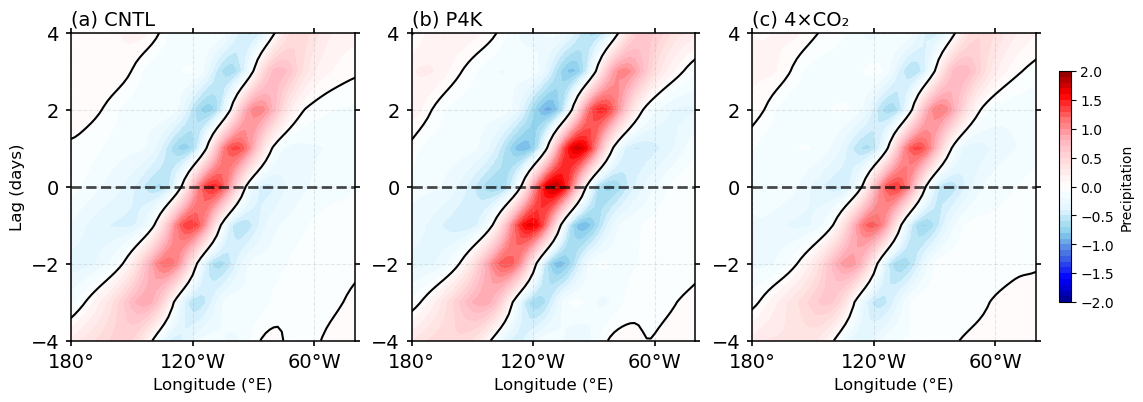

In [43]:
def plot_hovmoller_composite(composites, experiments=None, lat_avg=slice(0, 10), 
                             figsize=(16, 10), levels=None, cmap='RdBu_r',
                             speed_results=None):
    """
    绘制 Hovmöller 图（时间-经度），可叠加传播速度轨迹
    
    Parameters:
    -----------
    composites : dict
        {exp_name: composite_data}
    experiments : list, optional
        要绘制的实验列表
    lat_avg : slice
        纬向平均的纬度范围
    figsize : tuple
        图像大小
    levels : array-like, optional
        等值线层级
    cmap : str
        色标
    speed_results : dict, optional
        传播速度分析结果，如果提供则在图上叠加最大值轨迹
    """
    if experiments is None:
        experiments = list(composites.keys())
    titles = ["(a) CNTL","(b) P4K",r"(c) 4×CO₂"]
    n_exp = len(experiments)
    fig, axes = plt.subplots(1 ,n_exp, figsize=figsize)
    
    if n_exp == 1:
        axes = [axes]
    
    # 定义颜色（醒目的颜色用于叠加曲线）
    exp_colors = {'CNTL': '#FFD700', 'P4K': '#FF1493', '4CO2': '#00FFFF'}
    
    for i, exp in enumerate(experiments):
        ax = axes[i]
        composite = composites[exp]
        
        # 纬向平均
        composite_lat_avg = composite.sel(lat=lat_avg).mean(dim='lat')
        
        # 自动设置等值线层级
        if levels is None:
            vmax = np.abs(composite_lat_avg).max().values
            levels_auto = np.linspace(-vmax, vmax, 21)
        else:
            levels_auto = levels
        
        # 绘制 Hovmöller 图
        cf = ax.contourf(
            composite_lat_avg.lon, 
            composite_lat_avg.lag,
            composite_lat_avg.values,
            levels=np.linspace(-2,2,41),
            cmap=mycmap,
            extend='neither'
        )
        
        # 添加零线
        ax.contour(
            composite_lat_avg.lon,
            composite_lat_avg.lag,
            composite_lat_avg.values,
            levels=[0],
            colors='black',
            linewidths=1.5,
            linestyles='-'
        )
        
        # ========== 新增：叠加最大值轨迹曲线 ==========
        if speed_results is not None and exp in speed_results:
            result = speed_results[exp]
            lon_pos = result['lon_positions']
            lag_days = result['lag_days']
            
            # 绘制实际最大值位置（散点）
            ax.scatter(lon_pos, lag_days, 
                      c=exp_colors.get(exp, 'yellow'),
                      s=60, 
                      marker='o',
                      edgecolors='white',
                      linewidths=2,
                      zorder=10,
                      label=f'Max positions')
            
            # 绘制拟合的传播轨迹线
            speed_deg = result['speed_deg_per_day']
            lag_fit = np.linspace(lag_days.min(), lag_days.max(), 100)
            intercept = lon_pos[0] - speed_deg * lag_days[0]
            lon_fit = speed_deg * lag_fit + intercept
            
            ax.plot(lon_fit, lag_fit,
                   color=exp_colors.get(exp, 'yellow'),
                   linestyle='-',
                   linewidth=3,
                   alpha=0.9,
                   zorder=9,
                   label=f'{speed_deg:.2f}°/day ')
            
            # 添加图例
            ax.legend(loc='lower right', fontsize=8.5, frameon=True, 
                     fancybox=True, shadow=True, framealpha=0.85,
                     edgecolor='gray')
        # =============================================
        
        # 添加 Day 0 参考线
        ax.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.7)
        xticks = np.arange(0, 361, 60)
        yticks = np.arange(-15, 16, 5)
        ax.set_xticks(xticks)
        # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
        lon_formatter = LongitudeFormatter(zero_direction_label=False)#True/False
        # lat_formatter = LatitudeFormatter()
        ax.xaxis.set_major_formatter(lon_formatter)
        # ax.yaxis.set_major_formatter(lat_formatter)
        # 设置标签
        ax.set_xlabel('Longitude (°E)', fontsize=12)
        if i ==0:
            
            ax.set_ylabel('Lag (days)', fontsize=12)
        ax.set_title(f'{titles[i]}  ', 
                    fontsize=14, loc='left')
        ax.set_xlim(180,320)
            
        ax.spines[['right','left','top','bottom']].set_linewidth(1.1) 
        ax.spines[['right','left','top','bottom']].set_visible(True) 
        ax.tick_params(    which='both',direction='out',
               width=1.2,
                    pad=5, 
                    labelsize=14,
                    bottom=True, left=True, right=True, top=True)

        # 设置经度刻度
        # ax.set_xticks(np.arange(180, 301, 30))
        ax.grid(True, alpha=0.3, linestyle='--')
     # 添加色标
    cbar = plt.colorbar(cf, ax=axes, orientation='vertical', pad=0.02,
                        shrink=0.75,
                        aspect=20)
    cbar.set_label('Precipitation', fontsize=10)
    
  
    
    # 保存图像
    save_path = os.path.join(FIG_SAVE_DIR, 'composite_hovmoller.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"💾 Figure saved: {save_path}")
    
    return fig

# 绘制 Hovmöller 图
print("\n🎨 Plotting Hovmöller diagrams...")
fig_hov = plot_hovmoller_composite(
    pr_composites, 
    experiments=EXPERIMENTS,
    lat_avg=EQUATOR_LAT,  # 0-10°N 平均
    cmap='RdBu_r',
    figsize=(15,4.)
)
plt.show()

In [44]:
from scipy.stats import linregress
from scipy.ndimage import maximum_filter

def calculate_propagation_speed(composite, lat_avg=slice(0, 10), 
                                lon_range=slice(180, 320), 
                                lag_range=slice(-4, 5),
                                threshold_percentile=50):
    """
    计算Hovmöller图中正异常信号的传播速度 - 使用连续追踪策略
    
    方法：
    1. 从lag=0开始，在目标区域找到最强的正异常中心
    2. 对于其他lag，在前一个位置附近搜索（局部追踪）
    3. 使用线性回归拟合 经度 vs 时间（lag）
    4. 斜率即为传播速度（度/天）
    
    Parameters:
    -----------
    composite : xr.DataArray
        复合场数据 (lag, lat, lon)
    lat_avg : slice
        纬向平均范围
    lon_range : slice
        考虑的经度范围
    lag_range : slice
        考虑的时间范围
    threshold_percentile : float
        只考虑大于此百分位数的正异常
    
    Returns:
    --------
    speed_deg_per_day : float
        传播速度（度/天）
    speed_m_per_s : float
        传播速度（m/s）
    r_squared : float
        拟合的R²值
    lon_positions : array
        每个lag对应的经度位置
    lag_days : array
        时间序列
    """
    # 1. 纬向平均
    composite_lat_avg = composite.sel(lat=lat_avg).mean(dim='lat')
    
    # 2. 选择经度和时间范围
    data = composite_lat_avg.sel(lon=lon_range)
    
    # 3. 只保留正异常
    data_positive = data.where(data > 0, 0)
    
    # 4. 使用局部追踪策略找到连续传播的正异常中心
    lon_positions = []
    lag_days = []
    
    # 首先找到lag=0的最大值位置作为起点
    lag0_data = data_positive.sel(lag=0)
    if lag0_data.max().values > 0:
        center_lon = lag0_data.lon.values[lag0_data.argmax().values]
    else:
        # 如果lag=0没有正异常，使用整个区域的最大值
        center_lon = data.sel(lag=0).lon.values[data.sel(lag=0).argmax().values]
    
    # 设置搜索窗口（度数）
    search_window = 30  # 在前一个位置±30°范围内搜索
    
    # 按时间顺序追踪（先负lag，再正lag）
    sorted_lags = sorted(data.lag.values)
    
    for i, lag in enumerate(sorted_lags):
        lag_data_positive = data_positive.sel(lag=lag)
        
        if i == 0 or len(lon_positions) == 0:
            # 第一个lag或之前没有找到点：在整个区域搜索
            search_region = lag_data_positive
        else:
            # 后续lag：在上一个位置附近搜索
            prev_lon = lon_positions[-1]
            lon_min = max(data.lon.values.min(), prev_lon - search_window)
            lon_max = min(data.lon.values.max(), prev_lon + search_window)
            search_region = lag_data_positive.sel(lon=slice(lon_min, lon_max))
        
        # 在搜索区域内找最大值
        if search_region.max().values > 0:
            max_lon = search_region.lon.values[search_region.argmax().values]
            lon_positions.append(max_lon)
            lag_days.append(lag)
        else:
            # 如果搜索区域没有正异常，扩大搜索范围
            if lag_data_positive.max().values > 0:
                max_lon = lag_data_positive.lon.values[lag_data_positive.argmax().values]
                lon_positions.append(max_lon)
                lag_days.append(lag)
    
    lon_positions = np.array(lon_positions)
    lag_days = np.array(lag_days)
    
    # 6. 线性回归：lon = a * lag + b
    if len(lag_days) < 3:
        return None, None, None, None, None
    
    slope, intercept, r_value, p_value, std_err = linregress(lag_days, lon_positions)
    
    # 7. 计算传播速度
    speed_deg_per_day = slope  # 度/天
    
    # 转换为 m/s（假设在赤道附近，1度 ≈ 111 km）
    speed_m_per_s = (slope * 111000) / (24 * 3600)  # m/s
    
    r_squared = r_value ** 2
    
    return speed_deg_per_day, speed_m_per_s, r_squared, lon_positions, lag_days


def analyze_all_propagation_speeds(composites, experiments=None, 
                                   lat_avg=slice(0, 10),
                                   lon_range=slice(180, 320)):
    """
    分析所有实验的传播速度
    """
    if experiments is None:
        experiments = list(composites.keys())
    
    results = {}
    
    print("\n" + "="*80)
    print("📊 CCKW Propagation Speed Analysis")
    print("="*80)
    
    for exp in experiments:
        composite = composites[exp]
        
        speed_deg, speed_ms, r2, lon_pos, lag_days = calculate_propagation_speed(
            composite, 
            lat_avg=lat_avg,
            lon_range=lon_range,
            threshold_percentile=50
        )
        
        if speed_deg is not None:
            results[exp] = {
                'speed_deg_per_day': speed_deg,
                'speed_m_per_s': speed_ms,
                'r_squared': r2,
                'lon_positions': lon_pos,
                'lag_days': lag_days
            }
            
            print(f"\n🔍 {exp}:")
            print(f"   传播速度: {speed_deg:.2f} °/day  ({speed_ms:.2f} m/s)")
            print(f"   拟合质量 (R²): {r2:.4f}")
            print(f"   数据点数: {len(lag_days)}")
        else:
            print(f"\n⚠️  {exp}: 无法计算传播速度（信号太弱或数据不足）")
    
    # 计算速度变化
    if len(results) >= 2:
        print("\n" + "="*80)
        print("📈 速度变化对比（相对于 CNTL）")
        print("="*80)
        
        if 'CNTL' in results:
            cntl_speed = results['CNTL']['speed_m_per_s']
            
            for exp in results:
                if exp == 'CNTL':
                    continue
                
                exp_speed = results[exp]['speed_m_per_s']
                speed_change = exp_speed - cntl_speed
                speed_change_pct = (speed_change / cntl_speed) * 100
                
                print(f"\n{exp} vs CNTL:")
                print(f"   速度变化: {speed_change:+.2f} m/s  ({speed_change_pct:+.1f}%)")
                
                if speed_change > 0:
                    print(f"   ✅ 传播速度加快")
                elif speed_change < 0:
                    print(f"   ⚠️  传播速度减慢")
    
    print("\n" + "="*80)
    
    return results


# 执行传播速度分析
print("\n🚀 Computing propagation speeds...")
print(f"📍 使用与事件检测相同的区域:")
print(f"   纬度: {EQUATOR_LAT.start}°N - {EQUATOR_LAT.stop}°N")
print(f"   经度: {TARGET_LON.start}°E - {TARGET_LON.stop}°E")
print("="*80)

speed_results = analyze_all_propagation_speeds(
    pr_composites,
    experiments=EXPERIMENTS,
    lat_avg=EQUATOR_LAT,

)


🚀 Computing propagation speeds...
📍 使用与事件检测相同的区域:
   纬度: 0°N - 10°N
   经度: 240°E - 261°E

📊 CCKW Propagation Speed Analysis

🔍 CNTL:
   传播速度: 10.90 °/day  (14.00 m/s)
   拟合质量 (R²): 0.9992
   数据点数: 9

🔍 P4K:
   传播速度: 11.90 °/day  (15.29 m/s)
   拟合质量 (R²): 0.9991
   数据点数: 9

🔍 4CO2:
   传播速度: 10.97 °/day  (14.09 m/s)
   拟合质量 (R²): 0.9989
   数据点数: 9

📈 速度变化对比（相对于 CNTL）

P4K vs CNTL:
   速度变化: +1.28 m/s  (+9.2%)
   ✅ 传播速度加快

4CO2 vs CNTL:
   速度变化: +0.09 m/s  (+0.6%)
   ✅ 传播速度加快




🎨 Plotting Hovmöller diagrams with propagation tracks...


💾 Figure saved: ./figures/pr_regression_composite/composite_hovmoller.png

📌 图例说明:
   • 黄色/粉色/青色散点：每个lag时刻的实际降水最大值经度位置
   • 彩色实线：线性拟合的传播轨迹
   • R²值：拟合质量（越接近1表示传播越规则）
   • 速度值（°/day）：向东传播的速度


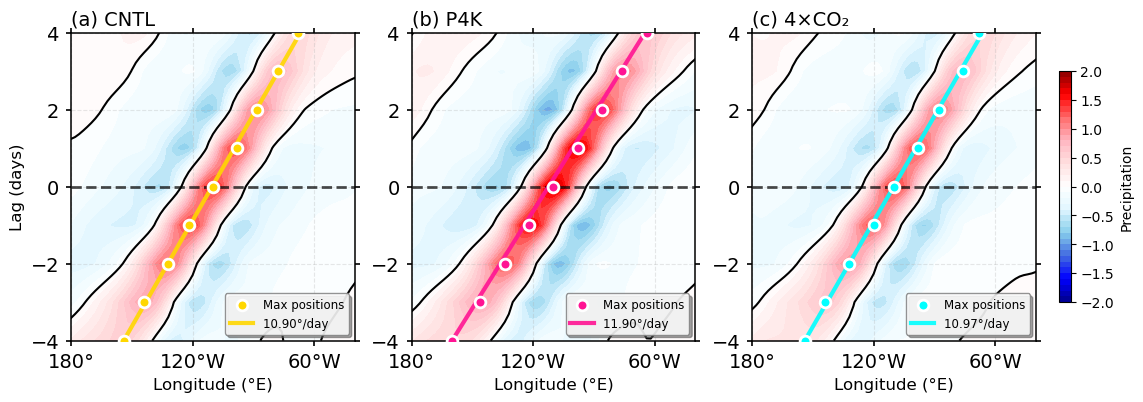

In [45]:
# 绘制带有传播速度轨迹的 Hovmöller 图
print("\n🎨 Plotting Hovmöller diagrams with propagation tracks...")
print("=" * 80)

fig_hov_with_tracks = plot_hovmoller_composite(
    pr_composites, 
    experiments=EXPERIMENTS,
    lat_avg=EQUATOR_LAT,  # 0-10°N 平均
    cmap='RdBu_r',
    figsize=(15, 4.),
    speed_results=speed_results  # 传入速度分析结果
)

print("\n📌 图例说明:")
print("   • 黄色/粉色/青色散点：每个lag时刻的实际降水最大值经度位置")
print("   • 彩色实线：线性拟合的传播轨迹")
print("   • R²值：拟合质量（越接近1表示传播越规则）")
print("   • 速度值（°/day）：向东传播的速度")
print("=" * 80)

plt.show()


🎨 Plotting propagation speed analysis...

💾 Figure saved: ./figures/pr_regression_composite/propagation_speed_analysis.png

💾 Figure saved: ./figures/pr_regression_composite/propagation_speed_analysis.png


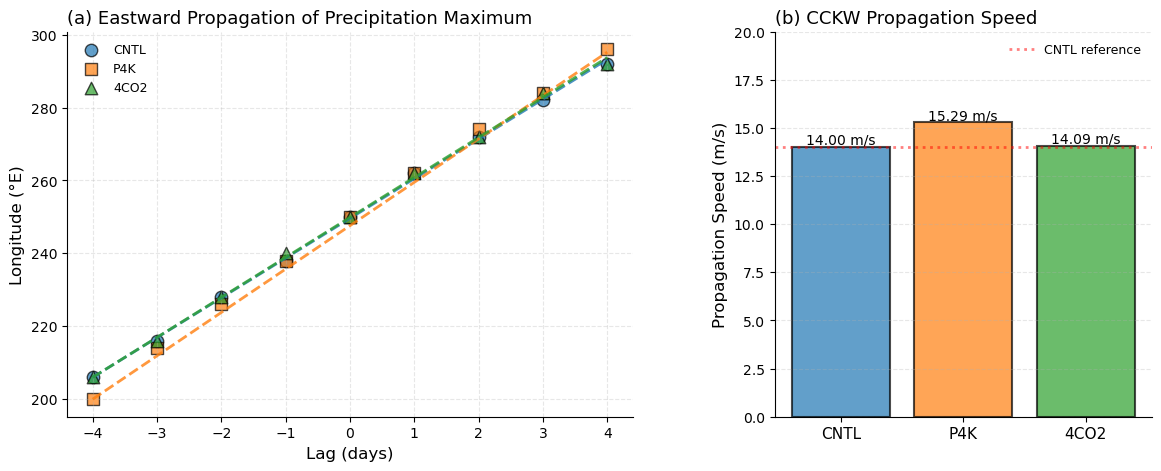

In [46]:
def plot_propagation_speed_analysis(speed_results, experiments=None, figsize=(14, 5)):
    """
    可视化传播速度分析结果
    
    绘制两个子图：
    1. 经度位置 vs 时间（lag）的散点图和拟合直线
    2. 传播速度柱状图对比
    """
    if experiments is None:
        experiments = list(speed_results.keys())
    
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[1.5, 1], wspace=0.3)
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    
    colors = {'CNTL': '#1f77b4', 'P4K': '#ff7f0e', '4CO2': '#2ca02c'}
    markers = {'CNTL': 'o', 'P4K': 's', '4CO2': '^'}
    
    # 子图1: 经度-时间散点图
    for exp in experiments:
        if exp not in speed_results:
            continue
        
        result = speed_results[exp]
        lon_pos = result['lon_positions']
        lag_days = result['lag_days']
        speed = result['speed_deg_per_day']
        r2 = result['r_squared']
        
        # 散点图
        ax1.scatter(lag_days, lon_pos, 
                   label=f'{exp}', 
                   color=colors.get(exp, 'gray'),
                   marker=markers.get(exp, 'o'),
                   s=80, alpha=0.7, edgecolors='black', linewidths=1)
        
        # 拟合直线
        lag_fit = np.linspace(lag_days.min(), lag_days.max(), 100)
        # 从速度results反推intercept
        intercept = lon_pos[0] - speed * lag_days[0]
        lon_fit = speed * lag_fit + intercept
        
        ax1.plot(lag_fit, lon_fit, 
                color=colors.get(exp, 'gray'),
                linestyle='--', linewidth=2, alpha=0.8,
                )
    
    ax1.set_xlabel('Lag (days)', fontsize=12, )
    ax1.set_ylabel('Longitude (°E)', fontsize=12, )
    ax1.set_title('(a) Eastward Propagation of Precipitation Maximum', 
                 fontsize=13 , loc='left')
    ax1.legend(loc='best', fontsize=9, framealpha=0.9,frameon=False)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.spines[['right', 'top']].set_visible(False)
    
    # 子图2: 传播速度柱状图
    speeds_ms = [speed_results[exp]['speed_m_per_s'] for exp in experiments if exp in speed_results]
    exp_labels = [exp for exp in experiments if exp in speed_results]
    exp_colors = [colors.get(exp, 'gray') for exp in exp_labels]
    
    bars = ax2.bar(range(len(exp_labels)), speeds_ms, 
                   color=exp_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # 添加数值标签
    for i, (bar, speed) in enumerate(zip(bars, speeds_ms)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{speed:.2f} m/s',
                ha='center', va='bottom', fontsize=10, )
    
    ax2.set_xticks(range(len(exp_labels)))
    ax2.set_xticklabels(exp_labels, fontsize=11)
    ax2.set_ylabel('Propagation Speed (m/s)', fontsize=12, )
    ax2.set_title('(b) CCKW Propagation Speed', 
                 fontsize=13,  loc='left')
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax2.spines[['right', 'top']].set_visible(False)
    ax2.set_ylim(0,20)
    # 添加参考线（如果有CNTL）
    if 'CNTL' in speed_results:
        cntl_speed = speed_results['CNTL']['speed_m_per_s']
        ax2.axhline(y=cntl_speed, color='red', linestyle=':', 
                   linewidth=2, alpha=0.5, label='CNTL reference')
        ax2.legend(loc='upper right', fontsize=9,frameon=False)
    
    # plt.tight_layout()
    
    # 保存图像
    save_path = os.path.join(FIG_SAVE_DIR, 'propagation_speed_analysis.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\n💾 Figure saved: {save_path}")
    
    return fig


# 绘制传播速度分析图
print("\n🎨 Plotting propagation speed analysis...")
fig_speed = plot_propagation_speed_analysis(speed_results, experiments=EXPERIMENTS)
plt.show()

In [47]:
# 创建详细的统计表格
import pandas as pd

def create_speed_comparison_table(speed_results, experiments=None):
    """
    创建传播速度对比的详细表格
    """
    if experiments is None:
        experiments = list(speed_results.keys())
    
    table_data = []
    
    for exp in experiments:
        if exp not in speed_results:
            continue
        
        result = speed_results[exp]
        
        # 计算相对于CNTL的变化
        if 'CNTL' in speed_results and exp != 'CNTL':
            cntl_speed = speed_results['CNTL']['speed_m_per_s']
            speed_change = result['speed_m_per_s'] - cntl_speed
            speed_change_pct = (speed_change / cntl_speed) * 100
        else:
            speed_change = 0.0
            speed_change_pct = 0.0
        
        table_data.append({
            'Experiment': exp,
            'Speed (°/day)': f"{result['speed_deg_per_day']:.3f}",
            'Speed (m/s)': f"{result['speed_m_per_s']:.3f}",
            'Change vs CNTL (m/s)': f"{speed_change:+.3f}",
            'Change vs CNTL (%)': f"{speed_change_pct:+.2f}%",
            'R² (fit quality)': f"{result['r_squared']:.4f}",
            'Data points': len(result['lag_days'])
        })
    
    df = pd.DataFrame(table_data)
    
    print("\n" + "="*90)
    print("📋 CCKW Propagation Speed - Detailed Comparison Table")
    print("="*90)
    print(df.to_string(index=False))
    print("="*90)
    
    # 额外的物理解释
    print("\n💡 Physical Interpretation:")
    print("   - Typical CCKW speed: ~15-20 m/s (Wheeler & Kiladis, 1999)")
    print("   - Faster speeds may indicate:")
    print("     • Stronger convective coupling")
    print("     • Enhanced boundary layer moisture convergence")
    print("     • Modified tropical circulation patterns")
    print("   - R² > 0.9 indicates very strong linear eastward propagation")
    print("="*90)
    
    return df

# 生成对比表格
df_speeds = create_speed_comparison_table(speed_results, experiments=EXPERIMENTS)

# 保存表格为CSV
csv_path = os.path.join(FIG_SAVE_DIR, 'propagation_speed_comparison.csv')
df_speeds.to_csv(csv_path, index=False)
print(f"\n💾 Table saved: {csv_path}")


📋 CCKW Propagation Speed - Detailed Comparison Table
Experiment Speed (°/day) Speed (m/s) Change vs CNTL (m/s) Change vs CNTL (%) R² (fit quality)  Data points
      CNTL        10.900      14.003               +0.000             +0.00%           0.9992            9
       P4K        11.900      15.288               +1.285             +9.17%           0.9991            9
      4CO2        10.967      14.089               +0.086             +0.61%           0.9989            9

💡 Physical Interpretation:
   - Typical CCKW speed: ~15-20 m/s (Wheeler & Kiladis, 1999)
   - Faster speeds may indicate:
     • Stronger convective coupling
     • Enhanced boundary layer moisture convergence
     • Modified tropical circulation patterns
   - R² > 0.9 indicates very strong linear eastward propagation

💾 Table saved: ./figures/pr_regression_composite/propagation_speed_comparison.csv
